# Melanoma Dataset EDA

This notebook reads the dataset location from `config/train.yaml` and inspects the raw `train` and `test` image folders used by the project.

In [9]:
import math
import statistics
from collections import Counter
from pathlib import Path

import pandas as pd
import yaml
from IPython.display import display
from PIL import Image, ImageDraw, ImageOps

In [10]:
def find_repo_root(start: Path) -> Path:
    candidates = [start.resolve(), start.resolve().parent]
    for candidate in candidates:
        if (candidate / "config" / "train.yaml").exists():
            return candidate
    raise FileNotFoundError(f"Could not find repo root from {start}")


repo_root = find_repo_root(Path.cwd())
config_path = repo_root / "config" / "train.yaml"

with config_path.open("r", encoding="utf-8") as handle:
    config = yaml.safe_load(handle)

data_config = config["data"]
data_dir = repo_root / data_config["data_dir"]
train_dir = data_dir / data_config.get("train_subdir", "train")
test_dir = data_dir / data_config.get("val_subdir", "test")

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff", ".webp"}


def collect_split_records(split_dir: Path, split_name: str) -> list[dict]:
    if not split_dir.exists():
        raise FileNotFoundError(f"Missing split directory: {split_dir}")

    records = []
    class_dirs = sorted(path for path in split_dir.iterdir() if path.is_dir())
    for class_dir in class_dirs:
        for image_path in sorted(class_dir.rglob("*")):
            if image_path.suffix.lower() not in image_extensions:
                continue
            with Image.open(image_path) as image:
                width, height = image.size
                records.append({
                    "split": split_name,
                    "class_name": class_dir.name,
                    "path": image_path,
                    "width": width,
                    "height": height,
                    "mode": image.mode,
                })
    return records


train_records = collect_split_records(train_dir, "train")
test_records = collect_split_records(test_dir, "test")
all_records = train_records + test_records
classes = sorted({record["class_name"] for record in all_records})

print(f"Config path: {config_path}")
print(f"Dataset root: {data_dir}")
print(f"Train dir: {train_dir}")
print(f"Test dir: {test_dir}")
print(f"Validation mode in config: {data_config.get('val_mode')}")
print(f"Classes found: {classes}")

Config path: C:\Users\nrech\Documents\repositories\mse-mlops\config\train.yaml
Dataset root: C:\Users\nrech\Documents\repositories\mse-mlops\data\raw\melanoma_cancer_dataset
Train dir: C:\Users\nrech\Documents\repositories\mse-mlops\data\raw\melanoma_cancer_dataset\train
Test dir: C:\Users\nrech\Documents\repositories\mse-mlops\data\raw\melanoma_cancer_dataset\test
Validation mode in config: split
Classes found: ['benign', 'malignant']


In [11]:
def summarize_dimensions(records: list[dict]) -> dict:
    widths = [record["width"] for record in records]
    heights = [record["height"] for record in records]
    shapes = Counter((record["width"], record["height"]) for record in records)
    most_common_shape, most_common_count = shapes.most_common(1)[0]
    return {
        "samples": len(records),
        "min_width": min(widths),
        "max_width": max(widths),
        "min_height": min(heights),
        "max_height": max(heights),
        "median_width": int(statistics.median(widths)),
        "median_height": int(statistics.median(heights)),
        "most_common_shape": most_common_shape,
        "most_common_count": most_common_count,
    }


train_summary = summarize_dimensions(train_records)
test_summary = summarize_dimensions(test_records)

overview_df = pd.DataFrame([
    {
        "split": "train",
        "samples": train_summary["samples"],
        "width_range": f"{train_summary['min_width']} - {train_summary['max_width']}",
        "height_range": f"{train_summary['min_height']} - {train_summary['max_height']}",
        "median_size": f"{train_summary['median_width']} x {train_summary['median_height']}",
        "most_common_size": f"{train_summary['most_common_shape'][0]} x {train_summary['most_common_shape'][1]} ({train_summary['most_common_count']})",
    },
    {
        "split": "test",
        "samples": test_summary["samples"],
        "width_range": f"{test_summary['min_width']} - {test_summary['max_width']}",
        "height_range": f"{test_summary['min_height']} - {test_summary['max_height']}",
        "median_size": f"{test_summary['median_width']} x {test_summary['median_height']}",
        "most_common_size": f"{test_summary['most_common_shape'][0]} x {test_summary['most_common_shape'][1]} ({test_summary['most_common_count']})",
    },
])

print(f"Total samples: {len(all_records)}")
print(f"Number of classes: {len(classes)}")
print(f"Classes: {', '.join(classes)}")
display(overview_df)

Total samples: 10605
Number of classes: 2
Classes: benign, malignant


,split,samples,width_range,height_range,median_size,most_common_size
0,train,9605,300 - 300,300 - 300,300 x 300,300 x 300 (9605)
1,test,1000,300 - 300,300 - 300,300 x 300,300 x 300 (1000)


In [12]:
train_class_counts = Counter(record["class_name"] for record in train_records)
test_class_counts = Counter(record["class_name"] for record in test_records)

class_distribution_df = pd.DataFrame([
    {
        "class": class_name,
        "train": train_class_counts[class_name],
        "test": test_class_counts[class_name],
        "total": train_class_counts[class_name] + test_class_counts[class_name],
    }
    for class_name in classes
])

display(class_distribution_df)

,class,train,test,total
0,benign,5000,500,5500
1,malignant,4605,500,5105


Example images per class
benign


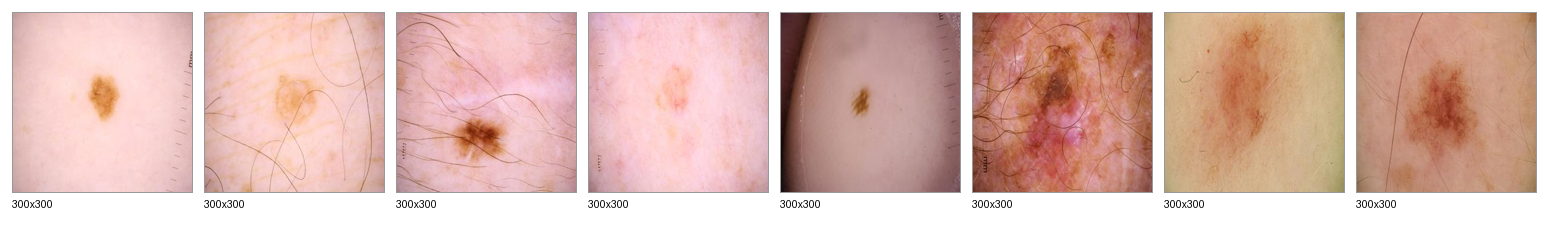

malignant


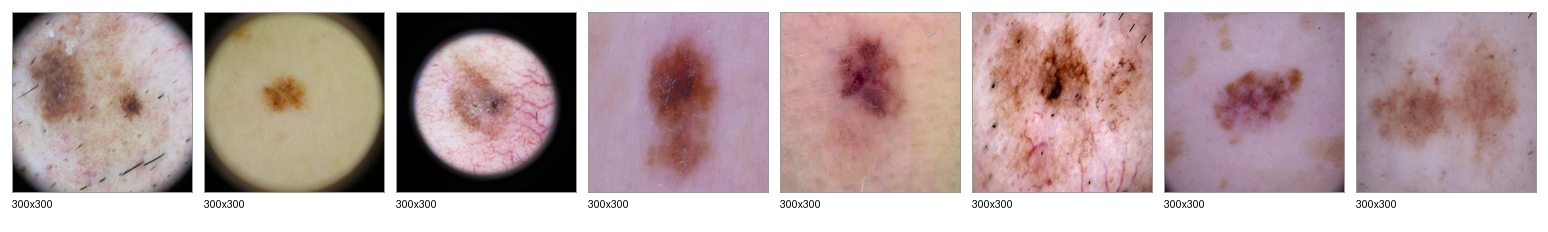

In [14]:
def make_contact_sheet(records: list[dict], thumb_size: tuple[int, int] = (180, 180), columns: int = 4) -> Image.Image:
    rows = math.ceil(len(records) / columns)
    margin = 12
    caption_height = 28
    canvas_width = columns * thumb_size[0] + (columns + 1) * margin
    canvas_height = rows * (thumb_size[1] + caption_height) + (rows + 1) * margin
    canvas = Image.new("RGB", (canvas_width, canvas_height), color="white")
    draw = ImageDraw.Draw(canvas)

    for index, record in enumerate(records):
        row = index // columns
        column = index % columns
        x = margin + column * thumb_size[0] + column * margin
        y = margin + row * (thumb_size[1] + caption_height) + row * margin

        with Image.open(record["path"]) as image:
            preview = ImageOps.contain(image.convert("RGB"), thumb_size)
        tile = Image.new("RGB", thumb_size, color="#f4f4f4")
        offset = ((thumb_size[0] - preview.width) // 2, (thumb_size[1] - preview.height) // 2)
        tile.paste(preview, offset)
        canvas.paste(tile, (x, y))
        draw.rectangle((x, y, x + thumb_size[0], y + thumb_size[1]), outline="#999999", width=1)
        draw.text((x, y + thumb_size[1] + 6), f"{record['width']}x{record['height']}", fill="black")

    return canvas


print("Example images per class")
samples_per_class = 8

for class_name in classes:
    class_records = [record for record in train_records if record["class_name"] == class_name]
    if len(class_records) < samples_per_class:
        class_records += [record for record in test_records if record["class_name"] == class_name]
    selected_records = class_records[:samples_per_class]
    print(class_name)
    display(make_contact_sheet(selected_records, columns=samples_per_class))